## FORMA 1 - GRADIENT DESCENT

El **descenso de gradiente** es un algoritmo de optimización que se utiliza para ajustar los parámetros de un modelo de regresión lineal. El objetivo es encontrar los valores de los parámetros que minimizan la función de costo, que mide la diferencia entre las predicciones del modelo y los valores reales.

El descenso de gradiente funciona iterativamente, actualizando los valores de los parámetros en cada iteración para reducir la función de costo. En cada iteración, se calcula el gradiente de la función de costo con respecto a los parámetros y se actualizan los parámetros en la dirección opuesta al gradiente. La tasa de aprendizaje controla el tamaño de los pasos que se dan en cada iteración.

Para aplicar el descenso de gradiente a un modelo de regresión lineal, se utiliza el **MSE** como función de costo. El MSE mide la diferencia entre las predicciones del modelo y los valores reales al cuadrado. El objetivo es minimizar el MSE ajustando los valores de los parámetros.


Paso a paso del algoritmo de descenso de gradiente para optimizar un modelo de regresión lineal:

1. Inicializa los parámetros del modelo con valores aleatorios.
2. Calcula la función de costo utilizando los valores actuales de los parámetros.
3. Calcula el gradiente de la función de costo con respecto a los parámetros.
4. Actualiza los parámetros en la dirección opuesta al gradiente multiplicado por la tasa de aprendizaje.
5. Repite los pasos 2-4 hasta que la función de costo converja a un mínimo o decidas parar.

COMO LO TENEIS QUE HACER VOSOTROS:

1. Inicializa los parametros `m` y `c` a cero o con valores aleatorios.
2. Elegimos un numero de iteraciones (eg. 100) y un ``learning_rate`` (eg. 0.01)
3. Inicializamos valores para X e Y. X que sean numpy arrays de 10 o 20 numeros (eg. range(10)) y la Y pueden ser parecida a la X pero con numeros arriba o abajo para simular aletoriedad (eg. 2,2,4,2,5,7,6,9,8,10)
4. Arrancamos el bucle for.
5. Calculamos la derivada del error respecto de `m` y `c`:
    - `dm = 2/n*sum((y-(m*x+c))*(-x))`
    - `dc = 2/n*sum((y-(m*x+c))*(-1))`
6. Actualizamos los parametros: `m=m-dm*lr` y `c=c-dc*lr`
7. Cada iteracion haceis un plot de la linea `x` y `m*x+c` respecto a los puntos originales (plot de x e y) y os guardais el las imagenes (Si haceis 100 iteraciones, tendreis 100 imagenes. Podeis valorar solo guardar por ejemplo cada 5 iteraciones por no hacer tantos plots).
8. Una vez terminamos printeamos m y c y con los plots generados teneis quer buscar alguna libreria en python y montar un gif con las imagenes de los plots:

![gif](https://th.bing.com/th/id/R.79e22f97090c346d704a68f7151e8cda?rik=oJV36GZyA1otdA&riu=http%3a%2f%2fcdn-images-1.medium.com%2fmax%2f640%2f1*eeIvlwkMNG1wSmj3FR6M2g.gif&ehk=0NUalJOl26VxY8ndNrkpV7GwYM1NVtJ5kMxU6jm5jB0%3d&risl=&pid=ImgRaw&r=0)

NOTA**: Todos los valores son orientativos. Podeis modificar los datos como querais. De hecho, os animo a que probeis y trasteeis.

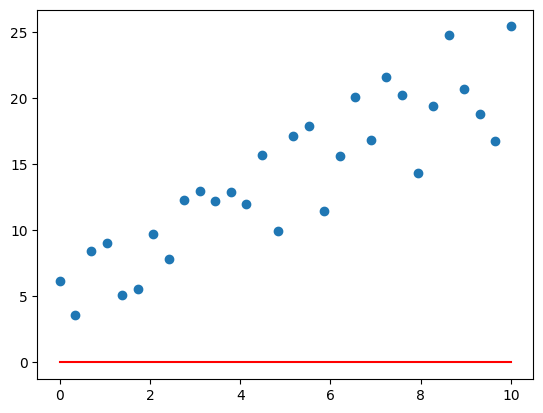

Pendiente inicial: 0
Punto de corte inicial:0
Mean Square Error inicial: 233.86487636742
Mejor pendiente: 1.7317237349404664
Mejor punto de corte:5.4734937231636716
Mean Square Error final: 7.053037769690822


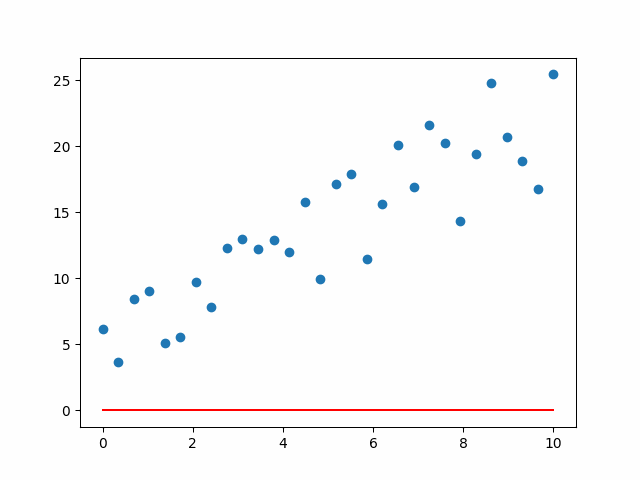

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from IPython.display import Image
import imageio.v2 as imageio
from glob import glob

#Declaramos las variable

num_interaciones = 700
learning_rate = 0.01
ruta_frames = "C:\\Users\\aritz\\Documents\\GitHub\\machine_learning\\notebooks\\Ejercicio_descenso_gradiente\\Frames"

#Creacion de los datos vamos a crear datos aleatorios 

longitud_datos = 30

#30 elementos entre 0 y 10
X = np.linspace(0, 10, longitud_datos)
#Creo esto para poder operar con X
Y = np.zeros(len(X))
#Vamos a crear una pendiente y un punto de corte real y luego le añadiremos ruido
m_real = np.sqrt(2)
c_real = np.pi

#Añadimos ruido un poco rebuscado para que no sea tan facil de predecir
ruido = np.random.randint(0, 5, longitud_datos)*np.exp(0.1*X)


#Estos son mis datos reales Y
Y = m_real * X + c_real + ruido

plt.scatter(X, Y)

#Creo una recta que por ahora tendra pendiente 0 y punto de corte 0
m = 0
c = 0

recta = [m * X[_] + c for _ in range(longitud_datos)]

plt.plot(X, recta, color = "red")
plt.show()

print(f"Pendiente inicial: {m}\nPunto de corte inicial:{c}")

#Voy a escribir primero la MSE inicial

MSE = 1/longitud_datos*sum([(Y[_]-recta[_])**2 for _ in range(longitud_datos)])
print(f"Mean Square Error inicial: {MSE}")

#Inicializamos el bucle donde ira el metodo de descenso de gradiente
mejor_m = 0
mejor_c = 0
contador = 0
while(contador < num_interaciones):
    #Creamos la nueva recta con los coeficientes que van cambiando
    nueva_recta = [m * X[_] + c for _ in range(longitud_datos)]

    #Calculamos las derivadas
    dm = 2/longitud_datos*sum([(Y[_]-nueva_recta[_])*(-X[_]) for _ in range(longitud_datos)])
    dc = 2/longitud_datos*sum([(Y[_]-nueva_recta[_])*(-1) for _ in range(longitud_datos)])

    #Actualizamos los parametros
    m = m - learning_rate * dm
    c = c -learning_rate * dc

    #Guardamos imagenes cada 50 iteraciones
    if contador % 25 == 0:
        plt.scatter(X, Y)
        plt.plot(X, nueva_recta, color = "red")
        plt.savefig(ruta_frames + f"\\iteracion_{contador:04d}.png")
        plt.close()

    mejor_m = m
    mejor_c = c

    contador += 1

#Ahora printeamos los coeficientes y la nueva MSE 
print(f"Mejor pendiente: {mejor_m}\nMejor punto de corte:{mejor_c}")

mejor_MSE = 1/longitud_datos*sum([(Y[_]-(mejor_m*X[_]+mejor_c))**2 for _ in range(longitud_datos)])

print(f"Mean Square Error final: {mejor_MSE}")

#Creamos la lista donde se van a guardar las imagenes
frames = []

#Usamos esto para pasar las imagenes a GIF y las mostramos
for filename in sorted(glob(ruta_frames + "\\iteracion_*.png")):
    frames.append(imageio.imread(filename))

imageio.mimsave("descenso_gradiente.gif", frames, duration = 0.4, loop = 0)

Image(filename="descenso_gradiente.gif")


# FORMA 2 - ECUACION NORMAL

El modelo de Linear Regression es unico en todo el universo ML. Es el unico que se puede resolver de forma analitica resolviendo una ecuacion sin necesidad de optimizar usando por ejemplo el descenso de gradiente. Para resolverlo se usa una ecuacion que se llama ECUACION NORMAL.

La ecuación normal es una forma de resolver la regresión lineal sin utilizar el descenso de gradiente. En lugar de iterar para encontrar los valores de los parámetros que minimizan la función de costo, la ecuación normal calcula los valores de los parámetros directamente.
La ecuación normal para la regresión lineal simple es:

$$\theta=(X^{T}X)^{−1}X^{T}y$$
Donde θ es el vector de parámetros, X es la matriz de características, y es el vector de valores objetivo y −1 denota la inversa de una matriz.
La ecuación normal se deriva al igualar el gradiente de la función de costo a cero. La solución resultante es la que minimiza la función de costo.

AQUI TENEIS LA FORMULA RESUELTA: https://interactivechaos.com/es/manual/tutorial-de-machine-learning/la-ecuacion-normal

Buscadla y aplicarla con vuestros datos de `X` e ``y``, y os calcula directamente los parametros ``m`` y ``c``.

Punto de corte segun la ecuación normal: 5.6156261999832084
Pendiente segun la ecuación normal: 1.710605102874218


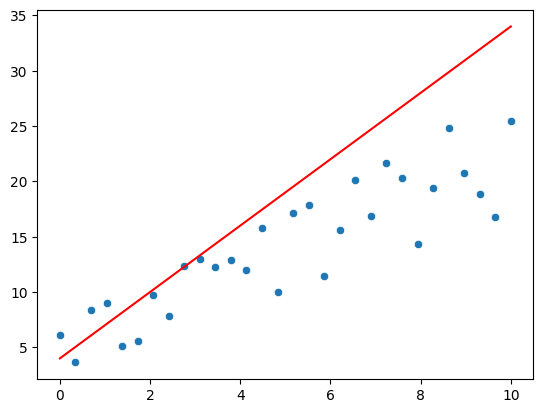

In [2]:
import seaborn as sns

#Ploteamos los datos que teniamos con el reshape necesario
sns.scatterplot(x = X.reshape(-1, ), y = Y.reshape(-1, ))
sns.lineplot(x = [0, 10], y = [4, 34], color = "red")

#Esto es para añadir un una a todos los datos delante
X_1 = np.c_[np.ones((longitud_datos, 1)), X]


#Sacamos los coeficientes de la regresion en la variable best_W
best_W = np.linalg.inv(X_1.T.dot(X_1)).dot(X_1.T).dot(Y)
print(f"Punto de corte segun la ecuación normal: {best_W[0]}\nPendiente segun la ecuación normal: {best_W[1]}")

# FORMA 3 - SKLEARN

Todos sabeis que si entrenamos un modelo de linear regression con sklearn podemos obtener los coeficientes con el metodo `.coef_` y el intercepto con `.intercept`.

Haz un fit del modelo con tus datos X e y, y comprueba que valores de coeficiente (m) y que valor de intercepto (c) te da



In [3]:
from sklearn.linear_model import LinearRegression

#Hacemos el reshape por que X tiene que tener esas dimensiones para sklearn
x = X.reshape(-1, 1)

#Fiteamos la regresion a nuestros datos
regresion = LinearRegression().fit(x, Y)

print(f"Punto de corte segun sklearn: {regresion.intercept_}\nPendiente segun sklearn: {regresion.coef_}")

Punto de corte segun sklearn: 5.615626199983222
Pendiente segun sklearn: [1.7106051]


# CIERRE

Si lo habeis hecho bien, los tres metodos os han debido dar valores para m y c que deberian ser identicos o suuuper parecidos. Haz un print de los parametros en una tabla para compararlos y verificar que son iguales, como se muestra a continuación. (NOTA***, los valores son de ejemplo, no los vuestros)

<center>

| **Variable** | **Gradient descendt** | **Ecuacion normal** | **sklearn** |
|-------------|-------------------|----------------------|---------------------|
|m    |  0.3454772825034164  |  0.34527687296416937  |  0.34527687  |
|c |  3.321256418022657  |  3.322475570032573  |  3.322475570032573  |


y=m * x + c

</center>

In [4]:
import pandas as pd

#Creo una tabla con los coeficiente de cada metodo

tabla = pd.DataFrame({
    "Variable": ["m", "c"],
    "Gradient descent": [mejor_m, mejor_c],
    "Ecuación normal": [best_W[1], best_W[0]],
    "Sklearn": [regresion.coef_, regresion.intercept_]
})

display(tabla)

,Variable,Gradient descent,Ecuación normal,Sklearn
0,m,1.731724,1.710605,[1.7106051028742164]
1,c,5.473494,5.615626,5.615626


## Podemos ver que con el descenso de gradiente el MSE es bastante bajo, aunque no tenemos una referencia como tal donde compararlo. Los hiperparametros seleccionados han sido escogidos por prueba y error, he visto que los mejores resultados (Sin tener que esperar 5 minutos por ejecución) estaban en el espectro de entre 500 y 1000 para las iteraciones y 0.005 y 0.01 para el learning rate. Ademas podemos observar como los coeficientes son muy cercanos a los otros metodos y obtener coeficiente por un metodo aproximativo muy parecidos a un metodo analítico es una bueña señal para descenso de gradiente.